# Poisson Kriging (Goovaerts) + GLGM / SPDE-style em Python

Exploração completa de dois padrões para **mapear risco de arboviroses** a partir de dados areais (casos / população):

| Método | Ideia | Neste notebook |
|--------|-------|----------------|
| **(B) Poisson Kriging** (Goovaerts) | Kriging de taxas $z(v)=d(v)/n(v)$ com termo de erro $\propto 1/n(v)$ na diagonal | implementação própria (NumPy) |
| **(C) GLGM / SPDE-style** | $Y_i \sim \mathrm{Poisson}(n_i e^{\beta_0+S_i})$, $S$ campo Gaussiano latente | **PyMC + MCMC** (GMRF/ICAR ≈ SPDE 2D) |

> **INLA-SPDE** clássico é R-INLA. Em Python puro o equivalente rigoroso é o mesmo modelo linear generalizado geoestatístico, inferido por MCMC (PyMC) ou Laplace. Usamos um **GMRF em grade** (aproximação SPDE de Lindgren et al.) — padrão moderno e escalável.

Dados: `zikario.gpkg` (Rio 2015–2016). Sem censo no repo → população **sintética independente dos casos** (para o $1/n$ fazer sentido sem circularidade).

Helpers: `dengue_envs.data.poisson_kriging`, `dengue_envs.data.model_based_geostats`.

## Teoria rápida — Poisson Kriging

Observamos contagens $d(v_\alpha)$ e população $n(v_\alpha)$ em áreas $v_\alpha$:

$$
z(v_\alpha) = \frac{d(v_\alpha)}{n(v_\alpha)}, \qquad
\mathbb{E}[z\mid R] = R, \qquad
\mathrm{Var}(z\mid R) \approx \frac{R}{n(v_\alpha)}
$$

Goovaerts modela a covariância das **taxas observadas** como

$$
C_z(v_\alpha, v_\beta)
= C_R(v_\alpha, v_\beta)
+ \delta_{\alpha\beta}\,\frac{m^*}{n(v_\alpha)}
$$

onde $m^*$ é a taxa média ponderada pela população e $C_R$ vem de um variograma do **risco** (aqui: esférico/exponencial ajustado às taxas, com o termo Poisson na krigagem).

O sistema de Ordinary Kriging com esse $C_z$ **automaticamente** dá menos peso a áreas com $n$ pequeno (taxas ruidosas).

---

## Teoria rápida — GLGM (modelo baseado)

$$
Y_i \sim \mathrm{Poisson}\big(n_i\,\lambda_i\big), \qquad
\log\lambda_i = \beta_0 + \mathbf{\beta}^\top \mathbf{w}_i + S_i
$$

$S = (S_1,\ldots,S_N)$ é um campo Gaussiano. Aqui usamos **ICAR/GMRF** na grade (vizinhos 4-conectados):

$$
S \sim \mathcal{N}\big(0,\, (\tau Q)^{-1}\big), \quad Q = D-W+\varepsilon I
$$

Isso é a forma discreta do SPDE Matérn em 2D (Lindgren, Rue, Lindström). Inferência: **NUTS/MCMC** via PyMC.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dengue_envs.data.kriging import (
    DEFAULT_RIO_BBOX_LONLAT,
    GridSpec,
    bbox_lonlat_to_projected,
    load_zikario_cases,
    normalize_probability,
)
from dengue_envs.data.poisson_kriging import (
    ArealRates,
    empirical_semivariogram,
    fit_variogram_least_squares,
    ordinary_kriging_rates,
    poisson_kriging,
    rate_covariance_matrix,
    synthetic_population_field,
)
from dengue_envs.data.model_based_geostats import (
    build_lattice_from_points,
    grid_adjacency_ic_ar,
    icar_precision,
    reshape_areal_to_grid,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 7)
rng = np.random.default_rng(0)

GPKG = ROOT / "dengue_envs" / "data" / "zikario.gpkg"
OUT = ROOT / "results" / "geostats"
OUT.mkdir(parents=True, exist_ok=True)
print("gpkg:", GPKG.exists(), "| out:", OUT)

gpkg: True | out: C:\Users\segun\Documents\GitHub\Dengue_Diagnostics\results\geostats


## 1. Dados: pontos → áreas (grade) + população sintética

Escolhemos uma grade **mais grossa** (~2 km) para:
- Poisson Kriging estável ($N$ áreas moderado);
- MCMC do GLGM viável em notebook.

Ajuste `CELL_M` se quiser mais/menos resolução.

In [2]:
CELL_M = 500.0  # tamanho da área (m) — aumente se MCMC ficar lento
DISEASE = "Dengue"  # troque para "Chikungunya" / "Zika"

cases = load_zikario_cases(
    GPKG,
    years=(2015, 2016),
    bbox_lonlat=DEFAULT_RIO_BBOX_LONLAT,
    diseases=("Dengue", "Chikungunya", "Zika"),
)
sub = cases[cases["Doenca"] == DISEASE]
print(sub["Doenca"].value_counts())

xmin, xmax, ymin, ymax = bbox_lonlat_to_projected(DEFAULT_RIO_BBOX_LONLAT)
grid = GridSpec(xmin, xmax, ymin, ymax, CELL_M)
print(f"grid {grid.nx}×{grid.ny} = {grid.nx * grid.ny} células")

lattice = build_lattice_from_points(
    sub["x"].to_numpy(),
    sub["y"].to_numpy(),
    grid,
    population=None,  # sintética independente
)
areal = lattice.to_areal()
print(f"áreas usadas: {areal.n_areas} | casos: {areal.cases.sum():.0f} | "
      f"pop total: {areal.population.sum():.0f} | m*={areal.mean_rate:.4e}")

Doenca
Dengue    52255
Name: count, dtype: int64
grid 145×91 = 13195 células
áreas usadas: 10593 | casos: 52255 | pop total: 21137963 | m*=2.4721e-03


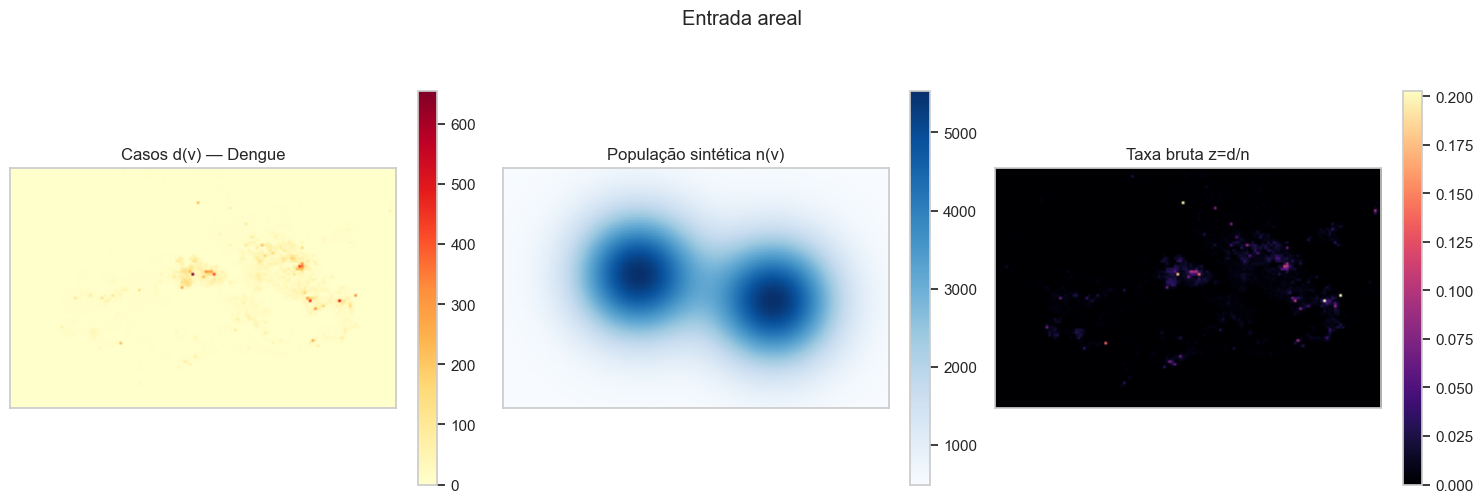

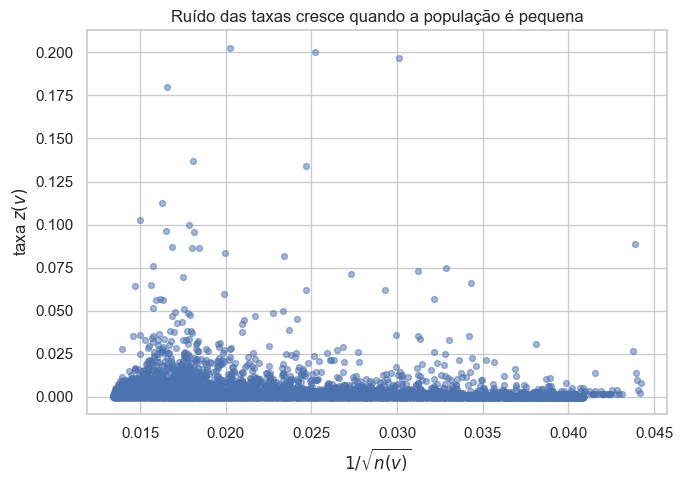

In [3]:
extent = [grid.xmin, grid.xmax, grid.ymin, grid.ymax]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(lattice.cases, origin="lower", extent=extent, aspect="equal", cmap="YlOrRd")
axes[0].set_title(f"Casos d(v) — {DISEASE}")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(lattice.population, origin="lower", extent=extent, aspect="equal", cmap="Blues")
axes[1].set_title("População sintética n(v)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

rates = lattice.rates
im2 = axes[2].imshow(rates, origin="lower", extent=extent, aspect="equal", cmap="magma")
axes[2].set_title("Taxa bruta z=d/n")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Entrada areal", y=1.02)
plt.tight_layout()
plt.show()

# Diagnóstico: taxas vs 1/sqrt(n) — áreas pequenas são mais ruidosas
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(1 / np.sqrt(areal.population), areal.rates, s=18, alpha=0.5)
ax.set_xlabel(r"$1/\sqrt{n(v)}$")
ax.set_ylabel(r"taxa $z(v)$")
ax.set_title("Ruído das taxas cresce quando a população é pequena")
plt.tight_layout()
plt.show()

## 2. Variograma empírico das taxas + ajuste

Ajustamos um modelo esférico/exponencial às taxas (exploratório). O termo Poisson entra **depois**, na matriz $C_z$.

VariogramParams(sill=np.float64(2.8819220131769454e-05), range_=np.float64(8671.915505688961), nugget=np.float64(2.9438988145355893e-05), model='spherical')


C:\Users\segun\AppData\Local\Temp\ipykernel_17004\3066361187.py:18: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\segun\Documents\GitHub\Dengue_Diagnostics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


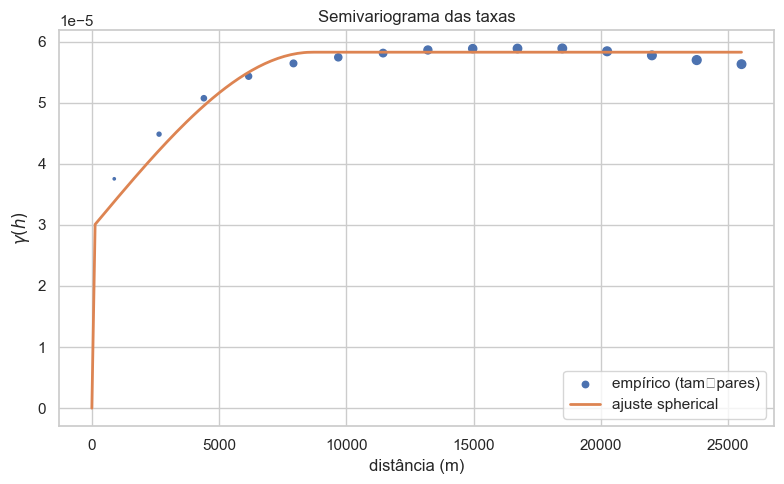

C_R(0)=5.8258e-05
poisson term: min=4.4739e-07 median=1.6587e-06 max=4.8377e-06
fração do termo Poisson vs C_R(0): median=2.85%


In [4]:
lag, gamma, counts = empirical_semivariogram(
    areal.coords(), areal.rates, n_lags=15, max_dist=None
)
vparams = fit_variogram_least_squares(lag, gamma, counts, model="spherical")
print(vparams)

h_plot = np.linspace(0, lag[-1], 200)
c0 = vparams.nugget + vparams.sill
gamma_hat = c0 - vparams.cov(h_plot)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(lag, gamma, s=40 * counts / counts.max(), c="C0", label="empírico (tam∝pares)")
ax.plot(h_plot, gamma_hat, "C1-", lw=2, label=f"ajuste {vparams.model}")
ax.set_xlabel("distância (m)")
ax.set_ylabel(r"$\gamma(h)$")
ax.set_title("Semivariograma das taxas")
ax.legend()
plt.tight_layout()
plt.show()

# Quanto o termo Poisson infla a diagonal?
cr0 = float(vparams.cov(np.array([0.0]))[0])
poisson_term = areal.mean_rate / areal.population
print(f"C_R(0)={cr0:.4e}")
print(
    f"poisson term: min={poisson_term.min():.4e} "
    f"median={np.median(poisson_term):.4e} max={poisson_term.max():.4e}"
)
print(f"fração do termo Poisson vs C_R(0): median={np.median(poisson_term)/cr0:.2%}")

## 3. Poisson Kriging vs Ordinary Kriging das taxas

Predição **area-to-point** nos centros da mesma grade (mapa suave do risco $\hat R(x)$).

Poisson Kriging...
Ordinary Kriging (sem termo 1/n)...


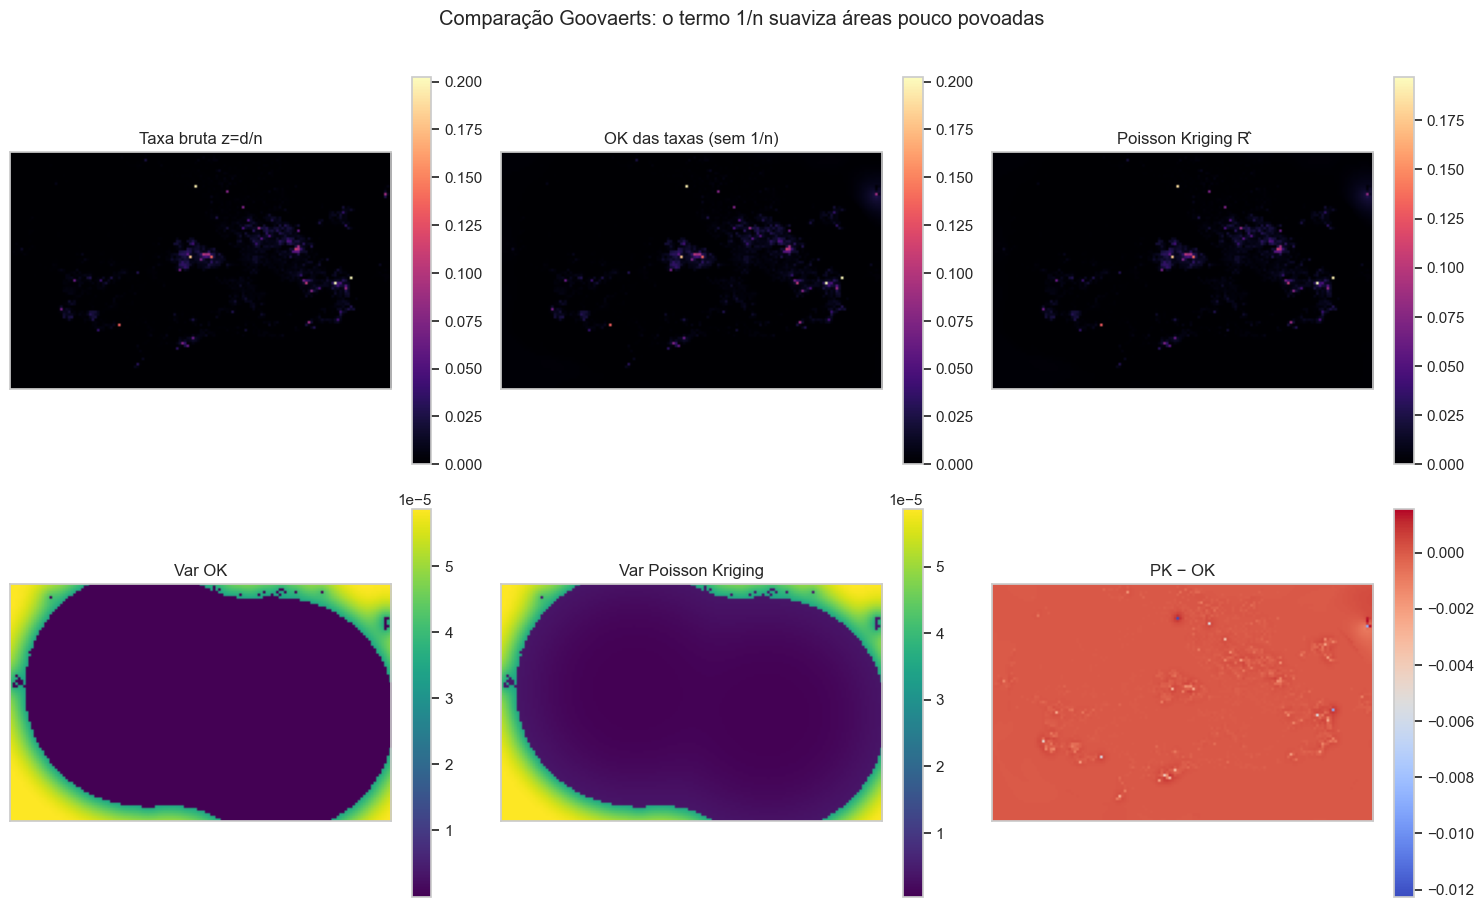

corr(PK, OK)=0.9997
mean |PK-OK| / mean(OK) = 3.02%


In [5]:
xs, ys = grid.centers()
XX, YY = np.meshgrid(xs, ys)
targets = np.column_stack([XX.ravel(), YY.ravel()])

print("Poisson Kriging...")
pk = poisson_kriging(areal, vparams, targets)
print("Ordinary Kriging (sem termo 1/n)...")
ok = ordinary_kriging_rates(areal, vparams, targets)

pk_map = pk.estimate.reshape(grid.ny, grid.nx)
ok_map = ok.estimate.reshape(grid.ny, grid.nx)
pk_var = pk.variance.reshape(grid.ny, grid.nx)
ok_var = ok.variance.reshape(grid.ny, grid.nx)
diff = pk_map - ok_map

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
panels = [
    (axes[0, 0], rates, "Taxa bruta z=d/n", "magma"),
    (axes[0, 1], ok_map, "OK das taxas (sem 1/n)", "magma"),
    (axes[0, 2], pk_map, "Poisson Kriging R̂", "magma"),
    (axes[1, 0], ok_var, "Var OK", "viridis"),
    (axes[1, 1], pk_var, "Var Poisson Kriging", "viridis"),
    (axes[1, 2], diff, "PK − OK", "coolwarm"),
]
for ax, data, title, cmap in panels:
    im = ax.imshow(data, origin="lower", extent=extent, aspect="equal", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Comparação Goovaerts: o termo 1/n suaviza áreas pouco povoadas", y=1.01)
plt.tight_layout()
plt.show()

print(f"corr(PK, OK)={np.corrcoef(pk.estimate, ok.estimate)[0,1]:.4f}")
print(f"mean |PK-OK| / mean(OK) = {np.mean(np.abs(diff))/np.mean(ok_map):.2%}")

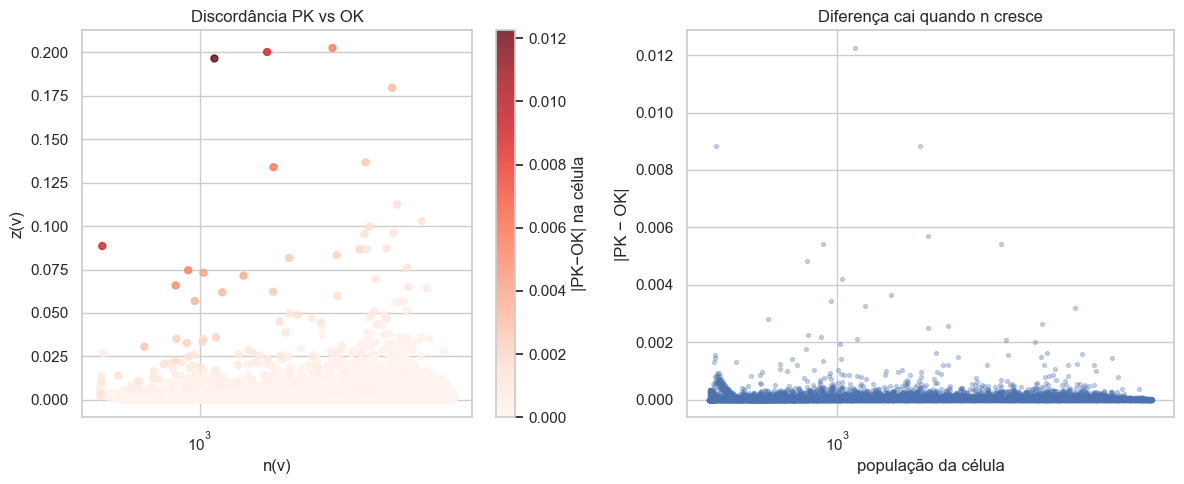

In [6]:
# Onde PK e OK discordam mais? Em geral onde n é pequeno e z é extremo
pop_map = lattice.population
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc = axes[0].scatter(areal.population, areal.rates, c=np.abs(
    # diferença no centróide: interpola pk-ok na célula
    np.abs(diff)[np.floor((areal.y-grid.ymin)/grid.cell_size).astype(int),
                 np.floor((areal.x-grid.xmin)/grid.cell_size).astype(int)]
), s=25, cmap="Reds", alpha=0.8)
plt.colorbar(sc, ax=axes[0], label="|PK−OK| na célula")
axes[0].set_xlabel("n(v)")
axes[0].set_ylabel("z(v)")
axes[0].set_title("Discordância PK vs OK")
axes[0].set_xscale("log")

axes[1].scatter(pop_map.ravel(), np.abs(diff).ravel(), s=8, alpha=0.3)
axes[1].set_xlabel("população da célula")
axes[1].set_ylabel("|PK − OK|")
axes[1].set_title("Diferença cai quando n cresce")
axes[1].set_xscale("log")
plt.tight_layout()
plt.show()

## 4. Experimento controlado: o efeito do $1/n$

Inflacionamos artificialmente a taxa em **áreas de baixa população** e vemos se o Poisson Kriging resiste melhor que o OK.

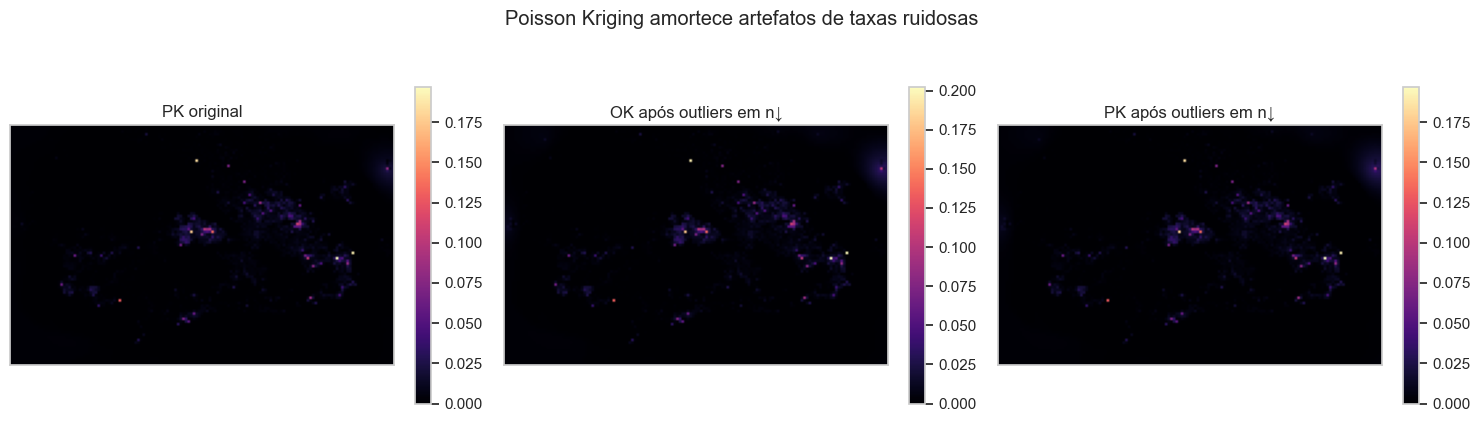

max OK ruidoso / max OK limpo: 0.9999999999998752
max PK ruidoso / max PK limpo: 0.9999499205177574


In [7]:
areal_noisy = ArealRates(
    x=areal.x.copy(),
    y=areal.y.copy(),
    cases=areal.cases.copy(),
    population=areal.population.copy(),
)
# Injeta outliers: nas 15 áreas de menor pop, multiplica casos (taxa explode)
idx_small = np.argsort(areal_noisy.population)[:15]
areal_noisy.cases[idx_small] = areal_noisy.cases[idx_small] + 5 * areal_noisy.population[idx_small] * areal.mean_rate

pk_n = poisson_kriging(areal_noisy, vparams, targets)
ok_n = ordinary_kriging_rates(areal_noisy, vparams, targets)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(pk_map, origin="lower", extent=extent, aspect="equal", cmap="magma")
axes[0].set_title("PK original")
im1 = axes[1].imshow(ok_n.estimate.reshape(grid.ny, grid.nx), origin="lower", extent=extent, aspect="equal", cmap="magma")
axes[1].set_title("OK após outliers em n↓")
im2 = axes[2].imshow(pk_n.estimate.reshape(grid.ny, grid.nx), origin="lower", extent=extent, aspect="equal", cmap="magma")
axes[2].set_title("PK após outliers em n↓")
for ax, im in zip(axes, (im0, im1, im2)):
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Poisson Kriging amortece artefatos de taxas ruidosas", y=1.05)
plt.tight_layout()
plt.show()

print("max OK ruidoso / max OK limpo:", ok_n.estimate.max() / ok.estimate.max())
print("max PK ruidoso / max PK limpo:", pk_n.estimate.max() / pk.estimate.max())

## 5. GLGM + GMRF (SPDE-style) com PyMC / MCMC

Modelo:

$$
Y_i \sim \mathrm{Poisson}(n_i e^{\eta_i}), \quad
\eta_i = \beta_0 + S_i, \quad
S \sim \mathcal{N}(0, (\tau Q)^{-1})
$$

$Q$ = precisão ICAR na grade (vizinhos ortogonais).

**Nota de runtime:** use `FAST_MCMC=True` na primeira passada (chains curtas). Sem compilador C++ (`g++`), o PyTensor fica mais lento — opcional: instalar build tools no Windows ou `conda install gxx`. Se travar, aumente `CELL_M` (ex.: 3000–5000) para reduzir $N$.

Para publicação, aumente draws/tune e use `FAST_MCMC=False`.

In [4]:
import arviz as az
import pymc as pm
import pytensor.tensor as pt

FAST_MCMC = True  # False para runs mais sérios
CELL_M = 2000.0  # tamanho da área (m) — aumente se MCMC ficar lento

# Usa só células habitadas (areal)
N = areal.n_areas
print(f"N áreas no GLGM: {N}")

# Adjacência na grade completa, depois restringe aos nós do areal
full_mask = lattice.inhabited & (lattice.population >= 1)
# garante que os nós do areal batem com mask
xs, ys = grid.centers()
XX, YY = np.meshgrid(xs, ys)
node_id = -np.ones((grid.ny, grid.nx), dtype=int)
active_ij = np.argwhere(full_mask)
for k, (i, j) in enumerate(active_ij):
    node_id[i, j] = k

# Remapeia areal → índices no full_mask
iy = np.floor((areal.y - grid.ymin) / grid.cell_size).astype(int)
ix = np.floor((areal.x - grid.xmin) / grid.cell_size).astype(int)
areal_nodes = node_id[iy, ix]
assert np.all(areal_nodes >= 0)

ei, ej = grid_adjacency_ic_ar(grid.ny, grid.nx, mask=full_mask)
n_nodes = int(full_mask.sum())
Q = icar_precision(n_nodes, ei, ej, epsilon=1e-3)
print(f"GMRF nodes={n_nodes} edges={len(ei)} | Q shape={Q.shape}")

# Dados alinhados à ordem active_ij
y_full = lattice.cases[full_mask]
n_full = lattice.population[full_mask]
log_n = np.log(n_full)

g++ not available, if using conda: `conda install gxx`


N áreas no GLGM: 10593
GMRF nodes=10593 edges=20906 | Q shape=(10593, 10593)


In [5]:
draws = 400 if FAST_MCMC else 1000
tune = 400 if FAST_MCMC else 1000
chains = 2 if FAST_MCMC else 4

coords = {"node": np.arange(n_nodes)}

with pm.Model(coords=coords) as glgm:
    beta0 = pm.Normal("beta0", mu=-8.0, sigma=3.0)
    # precisão espacial (maior tau → campo mais suave / menor variância)
    tau = pm.HalfNormal("tau", sigma=5.0)

    # S ~ N(0, (tau Q)^{-1})  via MvNormal com cov = chol(inv(tau Q))
    # Para N~100–300, MvNormal com precisão é ok se usarmos cov explícita
    cov = pt.linalg.solve(tau * pt.as_tensor_variable(Q), pt.eye(n_nodes))
    # simetriza + jitter numérico (ajuda sem g++ / PyTensor)
    cov = 0.5 * (cov + cov.T) + 1e-6 * pt.eye(n_nodes)
    S = pm.MvNormal("S", mu=0.0, cov=cov, shape=n_nodes, dims="node")

    eta = beta0 + S
    # offset de população: E(Y) = n * exp(eta)
    mu = pm.Deterministic("mu", pt.exp(log_n + eta))
    pm.Poisson("Y", mu=mu, observed=y_full)

    # risco relativo λ = exp(eta)
    pm.Deterministic("lambda", pt.exp(eta))

print(glgm)

with glgm:
    idata = pm.sample(
        draws=draws,
        tune=tune,
        chains=chains,
        target_accept=0.9,
        random_seed=0,
        progressbar=True,
        idata_kwargs={"log_likelihood": False},
    )

print(az.summary(idata, var_names=["beta0", "tau"], round_to=3))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta0, tau, S]


c:\Users\segun\Documents\GitHub\Dengue_Diagnostics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

: 

In [ ]:
az.plot_trace(idata, var_names=["beta0", "tau"])
plt.tight_layout()
plt.show()

# Diagnósticos MCMC
print(az.summary(idata, var_names=["beta0", "tau"], kind="diagnostics"))

In [ ]:
lam = idata.posterior["lambda"].stack(sample=("chain", "draw")).values  # (n_nodes, samples)
lam_mean = lam.mean(axis=1)
lam_sd = lam.std(axis=1)
lam_p025 = np.quantile(lam, 0.025, axis=1)
lam_p975 = np.quantile(lam, 0.975, axis=1)
exceed = (lam > np.median(lam_mean)).mean(axis=1)  # P(λ > mediana espacial)

def to_grid(vec):
    out = np.full((grid.ny, grid.nx), np.nan)
    out[full_mask] = vec
    return out

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
im0 = axes[0, 0].imshow(to_grid(lam_mean), origin="lower", extent=extent, aspect="equal", cmap="magma")
axes[0, 0].set_title(r"GLGM: média posterior $E[\lambda_i\mid Y]$")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(to_grid(lam_sd), origin="lower", extent=extent, aspect="equal", cmap="viridis")
axes[0, 1].set_title(r"Incerteza $sd(\lambda_i)$")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

im2 = axes[1, 0].imshow(to_grid(lam_p975 - lam_p025), origin="lower", extent=extent, aspect="equal", cmap="viridis")
axes[1, 0].set_title("Largura IC 95%")
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046)

im3 = axes[1, 1].imshow(to_grid(exceed), origin="lower", extent=extent, aspect="equal", cmap="coolwarm", vmin=0, vmax=1)
axes[1, 1].set_title(r"$P(\lambda_i > \mathrm{mediana})$")
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Posterior espacial do risco relativo (MCMC)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Comparar Poisson Kriging × GLGM

PK estima risco na escala da **taxa** $R \approx d/n$.  
GLGM estima $\lambda = e^{\beta_0+S}$ (taxa relativa com offset $n$).

Para comparar, olhamos correlação espacial e ranking de hotspots (ambos normalizados).

In [ ]:
# PK só nas células habitadas
pk_on_nodes = pk_map[full_mask]
glgm_on_nodes = lam_mean

# Normaliza para comparar forma espacial
pk_z = (pk_on_nodes - pk_on_nodes.mean()) / (pk_on_nodes.std() + 1e-12)
gl_z = (glgm_on_nodes - glgm_on_nodes.mean()) / (glgm_on_nodes.std() + 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(to_grid(pk_z), origin="lower", extent=extent, aspect="equal", cmap="coolwarm")
axes[0].set_title("PK (z-score)")
im1 = axes[1].imshow(to_grid(gl_z), origin="lower", extent=extent, aspect="equal", cmap="coolwarm")
axes[1].set_title("GLGM λ (z-score)")
im2 = axes[2].imshow(to_grid(gl_z - pk_z), origin="lower", extent=extent, aspect="equal", cmap="coolwarm")
axes[2].set_title("GLGM − PK (z)")
for ax, im in zip(axes, (im0, im1, im2)):
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

print("corr(PK, GLGM) =", np.corrcoef(pk_on_nodes, glgm_on_nodes)[0, 1])

# Top-10 hotspots
top_pk = set(np.argsort(pk_on_nodes)[-10:])
top_gl = set(np.argsort(glgm_on_nodes)[-10:])
print(f"overlap top-10 hotspots: {len(top_pk & top_gl)} / 10")

## 7. Extensão: covariáveis $\mathbf{w}(x)$ no GLGM

Exemplo didático: usar $\log n_i$ (densidade populacional sintética) e uma proxy espacial (coordenada normalizada) como covariáveis. Em um estudo real entrariam temperatura, precipitação, saneamento, etc.

In [ ]:
# Covariáveis nas células ativas
xc = XX[full_mask]
yc = YY[full_mask]
w1 = (xc - xc.mean()) / (xc.std() + 1e-12)  # leste-oeste
w2 = (yc - yc.mean()) / (yc.std() + 1e-12)  # norte-sul
w3 = (np.log(n_full) - np.log(n_full).mean()) / (np.log(n_full).std() + 1e-12)
W = np.column_stack([w1, w2, w3])

RUN_COVARIATES = FAST_MCMC  # rode sempre em modo rápido; desligue se quiser pular

if RUN_COVARIATES:
    with pm.Model(coords={"node": np.arange(n_nodes), "cov": ["x", "y", "logn"]}) as glgm_cov:
        beta0 = pm.Normal("beta0", 0.0, 3.0)
        beta = pm.Normal("beta", 0.0, 1.0, dims="cov")
        tau = pm.HalfNormal("tau", sigma=5.0)
        cov = pt.linalg.solve(tau * pt.as_tensor_variable(Q), pt.eye(n_nodes))
        cov = 0.5 * (cov + cov.T) + 1e-6 * pt.eye(n_nodes)
        S = pm.MvNormal("S", mu=0.0, cov=cov, shape=n_nodes)
        eta = beta0 + pt.dot(pt.as_tensor_variable(W), beta) + S
        mu = pt.exp(log_n + eta)
        pm.Poisson("Y", mu=mu, observed=y_full)
        pm.Deterministic("lambda", pt.exp(eta))

        idata_cov = pm.sample(
            draws=draws, tune=tune, chains=chains, target_accept=0.9,
            random_seed=1, progressbar=True, idata_kwargs={"log_likelihood": False},
        )
    print(az.summary(idata_cov, var_names=["beta0", "beta", "tau"], round_to=3))
else:
    print("Pulando GLGM com covariáveis (RUN_COVARIATES=False).")

## 8. Multi-doença (opcional, rápido)

Repete Poisson Kriging para Dengue / Chik / Zika e compara hotspots (mesma população sintética).

In [ ]:
pk_by_disease = {}
for d in ("Dengue", "Chikungunya", "Zika"):
    pts = cases[cases["Doenca"] == d]
    lat_d = build_lattice_from_points(pts["x"].to_numpy(), pts["y"].to_numpy(), grid, population=lattice.population)
    ar_d = lat_d.to_areal()
    # reusa variograma da doença foco (exploratório) — ideal: ajustar por doença
    lag_d, gam_d, cnt_d = empirical_semivariogram(ar_d.coords(), ar_d.rates, n_lags=12)
    vp_d = fit_variogram_least_squares(lag_d, gam_d, cnt_d, model="spherical")
    res = poisson_kriging(ar_d, vp_d, targets)
    pk_by_disease[d] = res.estimate.reshape(grid.ny, grid.nx)
    print(d, "m*=", f"{ar_d.mean_rate:.3e}", "range=", f"{vp_d.range_:.0f}m")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, d in zip(axes, pk_by_disease):
    im = ax.imshow(pk_by_disease[d], origin="lower", extent=extent, aspect="equal", cmap="magma")
    ax.set_title(f"PK — {d}")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Poisson Kriging por arbovírus (mesma grade/pop)", y=1.05)
plt.tight_layout()
plt.show()

# Probabilidade de classe espacial a partir dos riscos PK normalizados
stack = np.stack([normalize_probability(np.clip(pk_by_disease[d], 0, None)) for d in pk_by_disease], axis=0)
winner = stack.argmax(axis=0)
fig, ax = plt.subplots(figsize=(6, 6))
cmap = plt.matplotlib.colors.ListedColormap(["#1f77b4", "#ff7f0e", "#2ca02c"])
im = ax.imshow(winner, origin="lower", extent=extent, aspect="equal", cmap=cmap, vmin=0, vmax=2)
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2], fraction=0.046)
cbar.ax.set_yticklabels(list(pk_by_disease.keys()))
ax.set_title("Dominância espacial (arg max PK normalizado)")
plt.tight_layout()
plt.show()

## 9. Ponte com as ideias do notebook de mistura

| Ideia | Como encaixa aqui |
|-------|-------------------|
| **(B) Optimal transport** | Transportar o mapa `pk_map` / $E[\lambda]$ para outro suporte $S'$ (disco, duas cidades) |
| **(C) Copula / fatores latentes** | No GLGM, um $S$ compartilhado + cargas por doença (multi-output) |
| **(D) Tempo × espaço** | Repetir PK/GLGM por mês; ou $S_{i,t}$ com AR temporal |
| **(F) Range do variograma** | Já ajustamos `vparams.range_`; transferir só $(a,\mathrm{sill},\mathrm{nugget})$ a um grid sintético |

Abaixo: demo rápida de **(F)** — simular um campo com o mesmo range em um quadrado sintético — e esqueleto temporal.

In [ ]:
# (F) Transferir hiperparâmetros do variograma → campo sintético (Gaussian Process via cov)
from scipy.stats import multivariate_normal

L = 20000.0
synth = GridSpec(0, L, 0, L, cell_size=1000.0)
sxs, sys_ = synth.centers()
SX, SY = np.meshgrid(sxs, sys_)
pts = np.column_stack([SX.ravel(), SY.ravel()])
# subsample para cov densa
idx = rng.choice(len(pts), size=min(120, len(pts)), replace=False)
pts_s = pts[idx]
C = vparams.cov(np.linalg.norm(pts_s[:, None, :] - pts_s[None, :, :], axis=-1))
C = C + 1e-8 * np.eye(len(pts_s))
field = rng.multivariate_normal(np.zeros(len(pts_s)), C)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(pts_s[:, 0], pts_s[:, 1], c=field, cmap="coolwarm", s=40)
plt.colorbar(sc, ax=ax, label="campo latente simulado")
ax.set_aspect("equal")
ax.set_title(f"Campo sintético com range≈{vparams.range_:.0f} m (do Rio)")
plt.tight_layout()
plt.show()

In [ ]:
# (D) Fatia temporal: Poisson Kriging mês a mês (Dengue)
dengue = cases[cases["Doenca"] == "Dengue"].copy()
dengue["AnoMes"] = dengue["DT_SIN_PRI"].dt.to_period("M")
months = [m for m, n in dengue["AnoMes"].value_counts().sort_index().items() if n >= 400][:6]
print("meses:", months)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, month in zip(axes.ravel(), months):
    pts = dengue[dengue["AnoMes"] == month]
    lat_m = build_lattice_from_points(pts["x"], pts["y"], grid, population=lattice.population)
    ar_m = lat_m.to_areal()
    if ar_m.n_areas < 5:
        ax.set_axis_off()
        continue
    lag_m, gam_m, cnt_m = empirical_semivariogram(ar_m.coords(), ar_m.rates, n_lags=10)
    try:
        vp_m = fit_variogram_least_squares(lag_m, gam_m, cnt_m, model="spherical")
        pk_m = poisson_kriging(ar_m, vp_m, targets)
        ax.imshow(pk_m.estimate.reshape(grid.ny, grid.nx), origin="lower", extent=extent,
                  aspect="equal", cmap="magma")
    except Exception as e:
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha="center")
    ax.set_title(f"{month} (n={len(pts)})")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Poisson Kriging temporal (focos que acendem/apagam)", y=1.01)
plt.tight_layout()
plt.show()

## 10. Exportar resultados

In [ ]:
payload = {
    "disease": DISEASE,
    "cell_m": CELL_M,
    "xmin": grid.xmin,
    "xmax": grid.xmax,
    "ymin": grid.ymin,
    "ymax": grid.ymax,
    "cases": lattice.cases,
    "population": lattice.population,
    "rates": rates,
    "pk_estimate": pk_map,
    "pk_variance": pk_var,
    "ok_estimate": ok_map,
    "variogram_sill": vparams.sill,
    "variogram_range": vparams.range_,
    "variogram_nugget": vparams.nugget,
    "variogram_model": vparams.model,
    "glgm_lambda_mean": to_grid(lam_mean),
    "glgm_lambda_sd": to_grid(lam_sd),
    "inhabited_mask": full_mask.astype(np.uint8),
}
out_path = OUT / f"poisson_kriging_glgm_{DISEASE.lower()}.npz"
np.savez_compressed(out_path, **payload)
idata.to_netcdf(OUT / f"glgm_{DISEASE.lower()}.nc")
print("salvo:", out_path)
print("idata:", OUT / f"glgm_{DISEASE.lower()}.nc")

## Checklist de interpretação

1. **Taxas brutas** destacam áreas com $n$ pequeno? → se sim, PK deve suavizar mais que OK.
2. **Variograma**: range faz sentido na escala da cidade (km)? sill estável?
3. **PK vs OK**: diferenças concentradas em pop baixa?
4. **MCMC**: $\hat R$ (`r_hat`) ≈ 1, ESS decente para `beta0`/`tau`?
5. **GLGM vs PK**: hotspots batem? IC 95% largos onde há poucos casos?
6. **População sintética**: substituir por censo IBGE/bairro quando disponível — o pipeline não muda.

### Próximos passos no projeto
- Ligar `pk_map` / $E[\lambda]$ ao `KrigingDensityGenerator` / amostragem no env.
- Multi-doença com $S$ compartilhado (fator latente).
- SPDE com malha triangular (se migrar para R-INLA ou implementar FEM).
- OT para warp do mapa de risco a um suporte sintético (`generalizing_spatial_mixture.ipynb`).

```bash
poetry install
poetry run jupyter notebook notebooks/poisson_kriging_model_based_geostats.ipynb
```